In [2]:
# Crear dataset educativo con múltiples variables
import pandas as pd
import numpy as np

# Crear dataset de rendimiento estudiantil
np.random.seed(42)
n_estudiantes = 500

df = pd.DataFrame({
    'id_estudiante': range(1, n_estudiantes + 1),
    'edad': np.random.normal(16, 1.5, n_estudiantes).clip(14, 19).astype(int),
    'horas_estudio_semanal': np.random.normal(20, 8, n_estudiantes).clip(5, 50).astype(int),
    'promedio_calificaciones': np.random.normal(7.5, 1.2, n_estudiantes).clip(1, 10),
    'ingresos_familiares': np.random.lognormal(9, 0.6, n_estudiantes).round(0),
    'nivel_socioeconomico': np.random.choice(['Bajo', 'Medio', 'Alto'], n_estudiantes, p=[0.3, 0.5, 0.2]),
    'asistencia_clases': np.random.normal(85, 15, n_estudiantes).clip(10, 100).astype(int),
    'horas_extracurriculares': np.random.normal(8, 4, n_estudiantes).clip(0, 20).astype(int),
    'satisfaccion_vida': np.random.normal(7.2, 1.5, n_estudiantes).clip(1, 10),
    'nivel_estres': np.random.normal(6.8, 1.8, n_estudiantes).clip(1, 10)
})
df
df.describe()
df.info()


# Convertir variables categóricas
nivel_map = {'Bajo': 1, 'Medio': 2, 'Alto': 3}
df['nivel_socioeconomico_num'] = df['nivel_socioeconomico'].map(nivel_map)

print(f"Dataset creado: {len(df)} estudiantes")
print(f"Variables numéricas: {len(df.select_dtypes(include=[np.number]).columns)}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_estudiante            500 non-null    int64  
 1   edad                     500 non-null    int32  
 2   horas_estudio_semanal    500 non-null    int32  
 3   promedio_calificaciones  500 non-null    float64
 4   ingresos_familiares      500 non-null    float64
 5   nivel_socioeconomico     500 non-null    object 
 6   asistencia_clases        500 non-null    int32  
 7   horas_extracurriculares  500 non-null    int32  
 8   satisfaccion_vida        500 non-null    float64
 9   nivel_estres             500 non-null    float64
dtypes: float64(4), int32(4), int64(1), object(1)
memory usage: 31.4+ KB
Dataset creado: 500 estudiantes
Variables numéricas: 10


In [4]:
df
#df.describe()
#df.info()

,id_estudiante,edad,horas_estudio_semanal,promedio_calificaciones,ingresos_familiares,nivel_socioeconomico,asistencia_clases,horas_extracurriculares,satisfaccion_vida,nivel_estres,nivel_socioeconomico_num
0,1,16,27,9.179227,12926.0,Medio,62,11,7.089041,5.360107,2
1,2,15,35,8.609560,5821.0,Bajo,75,8,7.086502,3.365596,1
2,3,16,8,7.571556,4960.0,Medio,83,10,10.000000,6.092505,2
3,4,18,24,6.723676,8087.0,Bajo,63,20,5.121018,8.602937,1
4,5,15,14,8.337868,7317.0,Alto,71,0,7.958384,9.308218,3
...,...,...,...,...,...,...,...,...,...,...,...
495,496,16,17,9.907311,15399.0,Medio,100,8,6.956814,4.221192,2
496,497,14,34,9.973804,7975.0,Medio,79,11,7.414573,7.062506,2
497,498,15,25,8.950039,4774.0,Medio,90,8,8.474418,7.853539,2
498,499,14,15,8.728875,7348.0,Medio,87,1,8.239286,7.726790,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_estudiante             500 non-null    int64  
 1   edad                      500 non-null    int32  
 2   horas_estudio_semanal     500 non-null    int32  
 3   promedio_calificaciones   500 non-null    float64
 4   ingresos_familiares       500 non-null    float64
 5   nivel_socioeconomico      500 non-null    object 
 6   asistencia_clases         500 non-null    int32  
 7   horas_extracurriculares   500 non-null    int32  
 8   satisfaccion_vida         500 non-null    float64
 9   nivel_estres              500 non-null    float64
 10  nivel_socioeconomico_num  500 non-null    int64  
dtypes: float64(4), int32(4), int64(2), object(1)
memory usage: 35.3+ KB


In [6]:
df.describe()

,id_estudiante,edad,horas_estudio_semanal,promedio_calificaciones,ingresos_familiares,asistencia_clases,horas_extracurriculares,satisfaccion_vida,nivel_estres,nivel_socioeconomico_num
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.00000
mean,250.500000,15.610000,19.832000,7.621548,9825.686000,83.49000,7.506000,7.142315,6.658468,1.88600
std,144.481833,1.334715,7.685174,1.193663,6371.452164,12.69489,4.035162,1.470018,1.780271,0.69712
min,1.000000,14.000000,5.000000,4.024494,1388.000000,43.00000,0.000000,2.805827,1.386262,1.00000
25%,125.750000,14.000000,15.000000,6.777084,5613.250000,75.00000,5.000000,6.112482,5.555815,1.00000
50%,250.500000,16.000000,20.000000,7.643767,8060.000000,84.00000,8.000000,7.139461,6.707038,2.00000
75%,375.250000,16.000000,25.000000,8.405686,12331.000000,94.00000,10.000000,8.085981,7.828495,2.00000
max,500.000000,19.000000,41.000000,10.000000,55043.000000,100.00000,20.000000,10.000000,10.000000,3.00000


In [7]:
# Convertir variables categóricas
nivel_map = {'Bajo': 1, 'Medio': 2, 'Alto': 3}
df['nivel_socioeconomico_num'] = df['nivel_socioeconomico'].map(nivel_map)

print(f"Dataset creado: {len(df)} estudiantes")
print(f"Variables numéricas: {len(df.select_dtypes(include=[np.number]).columns)}")

Dataset creado: 500 estudiantes
Variables numéricas: 10


In [8]:
df

,id_estudiante,edad,horas_estudio_semanal,promedio_calificaciones,ingresos_familiares,nivel_socioeconomico,asistencia_clases,horas_extracurriculares,satisfaccion_vida,nivel_estres,nivel_socioeconomico_num
0,1,16,27,9.179227,12926.0,Medio,62,11,7.089041,5.360107,2
1,2,15,35,8.609560,5821.0,Bajo,75,8,7.086502,3.365596,1
2,3,16,8,7.571556,4960.0,Medio,83,10,10.000000,6.092505,2
3,4,18,24,6.723676,8087.0,Bajo,63,20,5.121018,8.602937,1
4,5,15,14,8.337868,7317.0,Alto,71,0,7.958384,9.308218,3
...,...,...,...,...,...,...,...,...,...,...,...
495,496,16,17,9.907311,15399.0,Medio,100,8,6.956814,4.221192,2
496,497,14,34,9.973804,7975.0,Medio,79,11,7.414573,7.062506,2
497,498,15,25,8.950039,4774.0,Medio,90,8,8.474418,7.853539,2
498,499,14,15,8.728875,7348.0,Medio,87,1,8.239286,7.726790,2


In [9]:
# Análisis de correlaciones por pares
# Correlaciones con calificaciones
correlaciones_calificaciones = df.corr()['promedio_calificaciones'].sort_values(ascending=False)

print("CORRELACIONES CON PROMEDIO DE CALIFICACIONES")
print("=" * 50)
for var, corr in correlaciones_calificaciones.items():
    if var != 'promedio_calificaciones':
        intensidad = "Fuerte" if abs(corr) > 0.6 else "Moderada" if abs(corr) > 0.3 else "Débil"
        direccion = "positiva" if corr > 0 else "negativa"
        print(f"{var:25} | {corr:+.3f} | {intensidad} {direccion}")

ValueError: could not convert string to float: 'Medio'

In [10]:
correlaciones_calificaciones = df.select_dtypes(include=['number']).corr()['promedio_calificaciones'].sort_values(ascending=False)

print("CORRELACIONES CON PROMEDIO DE CALIFICACIONES")
print("=" * 50)
for var, corr in correlaciones_calificaciones.items():
    if var != 'promedio_calificaciones':
        intensidad = "Fuerte" if abs(corr) > 0.6 else "Moderada" if abs(corr) > 0.3 else "Débil"
        direccion = "positiva" if corr > 0 else "negativa"
        print(f"{var:25} | {corr:+.3f} | {intensidad} {direccion}")

CORRELACIONES CON PROMEDIO DE CALIFICACIONES
horas_estudio_semanal     | +0.076 | Débil positiva
nivel_socioeconomico_num  | +0.060 | Débil positiva
satisfaccion_vida         | +0.009 | Débil positiva
id_estudiante             | -0.000 | Débil negativa
nivel_estres              | -0.014 | Débil negativa
asistencia_clases         | -0.031 | Débil negativa
ingresos_familiares       | -0.034 | Débil negativa
horas_extracurriculares   | -0.038 | Débil negativa
edad                      | -0.065 | Débil negativa


In [11]:
df_encoded = pd.get_dummies(df, drop_first=True)

correlaciones_calificaciones = df_encoded.corr()['promedio_calificaciones'].sort_values(ascending=False)

In [13]:
import pandas as pd

# Paso 1: Codificar variables categóricas ---
# Convierte todas las columnas categóricas en variables dummy (0/1)
# drop_first=True evita colinealidad (elimina la primera categoría como referencia)
df_encoded = pd.get_dummies(df, drop_first=True)

# Paso 2: Calcular correlaciones con 'promedio_calificaciones' ---
correlaciones_calificaciones = (
    df_encoded.corr()['promedio_calificaciones']
    .sort_values(ascending=False)
)

# Paso 3: Mostrar resultados con interpretación ---
print("CORRELACIONES CON PROMEDIO DE CALIFICACIONES")
print("=" * 50)
for var, corr in correlaciones_calificaciones.items():
    if var != 'promedio_calificaciones':
        intensidad = (
            "Fuerte" if abs(corr) > 0.6 else
            "Moderada" if abs(corr) > 0.3 else
            "Débil"
        )
        direccion = "positiva" if corr > 0 else "negativa"
        print(f"{var:25} | {corr:+.3f} | {intensidad} {direccion}")

CORRELACIONES CON PROMEDIO DE CALIFICACIONES
horas_estudio_semanal     | +0.076 | Débil positiva
nivel_socioeconomico_num  | +0.060 | Débil positiva
satisfaccion_vida         | +0.009 | Débil positiva
id_estudiante             | -0.000 | Débil negativa
nivel_estres              | -0.014 | Débil negativa
nivel_socioeconomico_Bajo | -0.015 | Débil negativa
asistencia_clases         | -0.031 | Débil negativa
ingresos_familiares       | -0.034 | Débil negativa
horas_extracurriculares   | -0.038 | Débil negativa
nivel_socioeconomico_Medio | -0.056 | Débil negativa
edad                      | -0.065 | Débil negativa


In [14]:
# Matriz de correlación completa
# Variables numéricas principales
variables_interes = ['edad', 'horas_estudio_semanal', 'promedio_calificaciones', 
                    'ingresos_familiares', 'asistencia_clases', 'horas_extracurriculares',
                    'satisfaccion_vida', 'nivel_estres', 'nivel_socioeconomico_num']

correlation_matrix = df[variables_interes].corr()

print("\nMATRIZ DE CORRELACIÓN")
print("=" * 25)
# Mostrar correlaciones > 0.3 en valor absoluto
strong_correlations = correlation_matrix.where(abs(correlation_matrix) > 0.3)
print(strong_correlations.round(3))


MATRIZ DE CORRELACIÓN
                          edad  horas_estudio_semanal  \
edad                       1.0                    NaN   
horas_estudio_semanal      NaN                    1.0   
promedio_calificaciones    NaN                    NaN   
ingresos_familiares        NaN                    NaN   
asistencia_clases          NaN                    NaN   
horas_extracurriculares    NaN                    NaN   
satisfaccion_vida          NaN                    NaN   
nivel_estres               NaN                    NaN   
nivel_socioeconomico_num   NaN                    NaN   

                          promedio_calificaciones  ingresos_familiares  \
edad                                          NaN                  NaN   
horas_estudio_semanal                         NaN                  NaN   
promedio_calificaciones                       1.0                  NaN   
ingresos_familiares                           NaN                  1.0   
asistencia_clases                   

In [15]:
# Análisis de correlaciones más fuertes
# Encontrar pares con correlaciones más fuertes
corr_unstack = correlation_matrix.unstack()
corr_unstack = corr_unstack[corr_unstack.index.get_level_values(0) != corr_unstack.index.get_level_values(1)]

top_correlations = corr_unstack.abs().sort_values(ascending=False).head(10)

print("\nTOP 10 CORRELACIONES MÁS FUERTES")
print("=" * 35)
for (var1, var2), corr_abs in top_correlations.items():
    if var1 < var2:  # Evitar duplicados
        corr_real = correlation_matrix.loc[var1, var2]
        print(f"{var1:20} ↔ {var2:20} | {corr_real:+.3f}")


TOP 10 CORRELACIONES MÁS FUERTES
asistencia_clases    ↔ horas_extracurriculares | -0.117
horas_estudio_semanal ↔ satisfaccion_vida    | -0.103
edad                 ↔ horas_estudio_semanal | -0.093
asistencia_clases    ↔ horas_estudio_semanal | -0.087
horas_estudio_semanal ↔ nivel_estres         | -0.079


In [16]:
# Análisis de grupos de variables correlacionadas
# Identificar clusters de variables relacionadas
print("\nANÁLISIS DE GRUPOS CORRELACIONADOS")
print("=" * 40)

# Variables relacionadas con rendimiento académico
academic_vars = ['horas_estudio_semanal', 'asistencia_clases', 'promedio_calificaciones']
academic_corr = df[academic_vars].corr()
print("Variables académicas:")
print(academic_corr.round(3))

# Variables relacionadas con bienestar
wellbeing_vars = ['satisfaccion_vida', 'nivel_estres', 'horas_extracurriculares']
wellbeing_corr = df[wellbeing_vars].corr()
print("\nVariables de bienestar:")
print(wellbeing_corr.round(3))

# Variables socioeconómicas
socio_vars = ['ingresos_familiares', 'nivel_socioeconomico_num', 'promedio_calificaciones']
socio_corr = df[socio_vars].corr()
print("\nVariables socioeconómicas:")
print(socio_corr.round(3))


ANÁLISIS DE GRUPOS CORRELACIONADOS
Variables académicas:
                         horas_estudio_semanal  asistencia_clases  \
horas_estudio_semanal                    1.000             -0.087   
asistencia_clases                       -0.087              1.000   
promedio_calificaciones                  0.076             -0.031   

                         promedio_calificaciones  
horas_estudio_semanal                      0.076  
asistencia_clases                         -0.031  
promedio_calificaciones                    1.000  

Variables de bienestar:
                         satisfaccion_vida  nivel_estres  \
satisfaccion_vida                    1.000         0.072   
nivel_estres                         0.072         1.000   
horas_extracurriculares             -0.033        -0.011   

                         horas_extracurriculares  
satisfaccion_vida                         -0.033  
nivel_estres                              -0.011  
horas_extracurriculares                   


Mapa de calor guardado como 'matriz_correlacion_estudiantil.png'


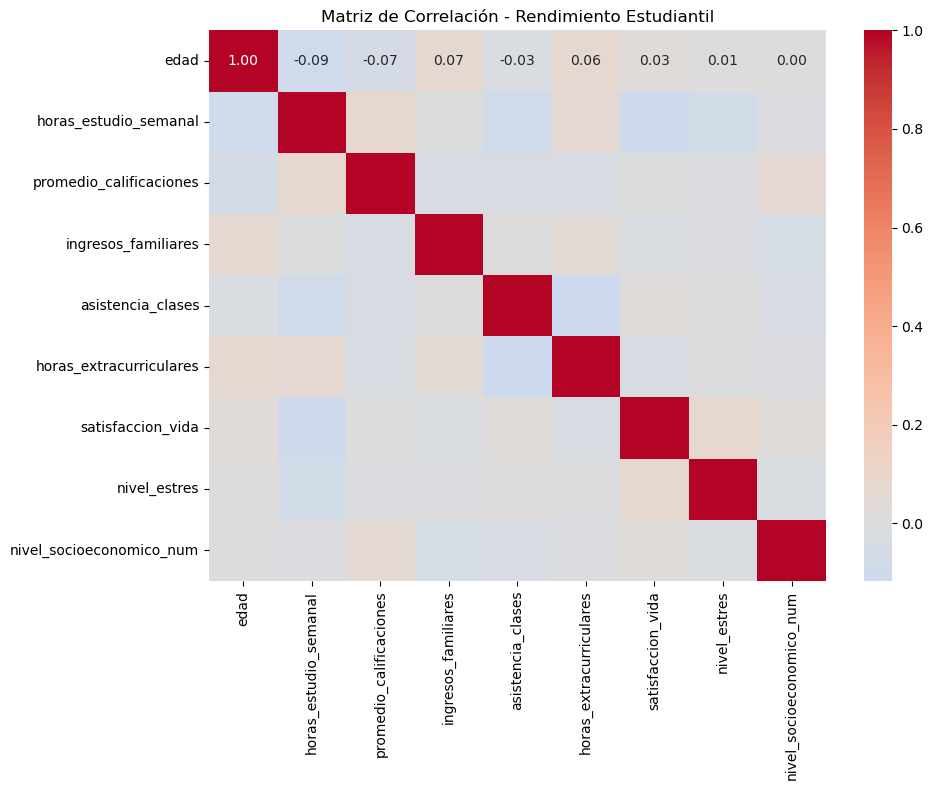

In [17]:
# Visualización de correlaciones (si matplotlib disponible)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Matriz de Correlación - Rendimiento Estudiantil')
    plt.tight_layout()
    plt.savefig('matriz_correlacion_estudiantil.png', dpi=100, bbox_inches='tight')
    print("\nMapa de calor guardado como 'matriz_correlacion_estudiantil.png'")
    
except ImportError:
    print("\nMatplotlib/Seaborn no disponibles - omitiendo visualización")

In [19]:
# Análisis de Grupos Correlacionados
#Conclusión académica: No hay correlaciones fuertes. 
#El rendimiento parece depender de factores adicionales (motivación, hábitos de estudio, apoyo externo).
#Conclusión bienestar: Las variables de bienestar no muestran correlaciones relevantes. 
#Esto sugiere que satisfacción y estrés no están directamente ligados a las actividades extracurriculares en este grupo. 
#Conclusión socioeconómica: El contexto económico no parece tener un impacto fuerte en el rendimiento académico dentro de este dataset.    
    

In [20]:
#Insights ejecutivos
#1. No hay correlaciones fuertes: el rendimiento estudiantil no se explica por horas de estudio, asistencia, ingresos o bienestar de manera directa.
#2. Posibles variables ocultas: motivación, calidad del estudio, apoyo docente, hábitos de sueño o concentración podrían ser más relevantes.
#3. Revisión de datos: algunas correlaciones contraintuitivas (ej. ingresos ↔ nivel socioeconómico) sugieren revisar cómo se definieron y codificaron las variables.
#4. Acción recomendada: complementar este análisis con modelos multivariados (regresión, árboles de decisión) para identificar combinaciones de factores que sí expliquen el rendimiento.